# Synthetic Raster-to-Vector Notebook: Junction-aware cleanup, no-hang merge

This version keeps the better junction coverage, but replaces the slow iterative merge with a bounded single-pass merge.

Key changes:

- `IMG_SIZE = 128`
- random synthetic data every full run
- minimum line length filter
- junction-aware endpoint snapping
- bounded merge step with diagnostics so it cannot loop indefinitely


In [1]:
# Optional: install missing packages if needed
# Run this cell only if imports fail.
# !pip install numpy matplotlib pillow tqdm


In [2]:
import math
import random
from dataclasses import dataclass
from collections import defaultdict, deque

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw


In [3]:
# -----------------------------
# Configuration
# -----------------------------
IMG_SIZE = 128
MAX_LINES = 5
LINE_WIDTH = 1
N_SAMPLES = 200
SEED = None  # None = different synthetic data every full notebook run

BLACK = 0
WHITE = 255
THRESHOLD_BLACKNESS = 0.50

# Minimum useful predicted vector length.
# 2.0 means at least 3 pixel positions along a straight line.
# 3.0 means at least 4 pixel positions.
MIN_LINE_LENGTH = 2.0

# Junction cleanup settings.
# Endpoints close to a detected junction are snapped to the junction centre.
# This reduces tiny fragments without leaving visible gaps at crossings.
JUNCTION_SNAP_RADIUS = 3.0
JUNCTION_INTERNAL_FRAGMENT_LENGTH = 4.0

if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)
# Safety cap for vector merging. Lower this if a sample is very complex.
MAX_MERGE_COMPARISONS = 5000
MERGE_DIAGNOSTICS = True


## 1. Synthetic vector generation

Each sample contains between 1 and 5 random straight-line vectors. The lines are rasterised as 1 px black strokes on a white 128×128 image.


In [4]:
@dataclass
class VectorLine:
    x1: float
    y1: float
    x2: float
    y2: float

    def as_tuple(self):
        return (self.x1, self.y1, self.x2, self.y2)


def random_line(img_size=128, min_length=8):
    while True:
        x1 = random.randint(2, img_size - 3)
        y1 = random.randint(2, img_size - 3)
        x2 = random.randint(2, img_size - 3)
        y2 = random.randint(2, img_size - 3)
        length = math.hypot(x2 - x1, y2 - y1)
        if length >= min_length:
            return VectorLine(x1, y1, x2, y2)


def generate_vector_sample(max_lines=5, img_size=128):
    n_lines = random.randint(1, max_lines)
    return [random_line(img_size=img_size) for _ in range(n_lines)]


def rasterise_vectors(lines, img_size=128, line_width=1):
    image = Image.new('L', (img_size, img_size), WHITE)
    draw = ImageDraw.Draw(image)
    for line in lines:
        draw.line((line.x1, line.y1, line.x2, line.y2), fill=BLACK, width=line_width)
    return np.array(image, dtype=np.uint8)


def make_dataset(n_samples=200):
    vectors = []
    rasters = []
    for _ in range(n_samples):
        lines = generate_vector_sample(MAX_LINES, IMG_SIZE)
        raster = rasterise_vectors(lines, IMG_SIZE, LINE_WIDTH)
        vectors.append(lines)
        rasters.append(raster)
    return vectors, np.stack(rasters)

true_vectors, raster_images = make_dataset(N_SAMPLES)
print(raster_images.shape)


(200, 128, 128)


## 2. Pixel thresholding

The rule is:

- if a pixel is at least 50% black, assign it as a dot;
- otherwise ignore it.

For 8-bit grayscale, blackness is calculated as:

```python
blackness = 1 - pixel_value / 255
```


In [5]:
def threshold_to_dots(raster, blackness_threshold=0.50):
    blackness = 1.0 - raster.astype(np.float32) / 255.0
    binary = blackness >= blackness_threshold
    return binary


def dot_coordinates(binary):
    ys, xs = np.where(binary)
    return list(zip(xs.tolist(), ys.tolist()))

binary_example = threshold_to_dots(raster_images[0])
print('Number of black/dot pixels:', binary_example.sum())


Number of black/dot pixels: 181


## 3. Connected components

This groups neighbouring black pixels. For line drawings, one connected component may contain multiple crossing lines, so connected components alone are not enough. We still use them to restrict tracing to local pixel regions.


In [6]:
NEIGHBOURS_8 = [
    (-1, -1), (0, -1), (1, -1),
    (-1,  0),          (1,  0),
    (-1,  1), (0,  1), (1,  1),
]


def in_bounds(x, y, img_size=128):
    return 0 <= x < img_size and 0 <= y < img_size


def get_binary_neighbours(binary, x, y):
    h, w = binary.shape
    out = []
    for dx, dy in NEIGHBOURS_8:
        nx, ny = x + dx, y + dy
        if 0 <= nx < w and 0 <= ny < h and binary[ny, nx]:
            out.append((nx, ny))
    return out


def connected_components(binary):
    h, w = binary.shape
    visited = np.zeros_like(binary, dtype=bool)
    components = []

    for y in range(h):
        for x in range(w):
            if not binary[y, x] or visited[y, x]:
                continue

            q = deque([(x, y)])
            visited[y, x] = True
            comp = []

            while q:
                px, py = q.popleft()
                comp.append((px, py))
                for nx, ny in get_binary_neighbours(binary, px, py):
                    if not visited[ny, nx]:
                        visited[ny, nx] = True
                        q.append((nx, ny))

            components.append(comp)

    return components

components = connected_components(binary_example)
print('Connected components:', len(components))
print('Component sizes:', [len(c) for c in components[:10]])


Connected components: 2
Component sizes: [128, 53]


## 4. Endpoints and intersections

A line pixel can be treated as a graph node.

- degree 1 usually means endpoint;
- degree 2 usually means normal line continuation;
- degree 3 or more usually means an intersection or junction.

Because diagonal raster lines can create small neighbourhood artefacts, the code also compresses nearby junction pixels into one junction cluster.


In [7]:
def pixel_degree(binary, x, y):
    return len(get_binary_neighbours(binary, x, y))


def classify_graph_pixels(binary):
    endpoints = set()
    junctions = set()
    normal = set()

    ys, xs = np.where(binary)
    for x, y in zip(xs, ys):
        deg = pixel_degree(binary, x, y)
        if deg <= 1:
            endpoints.add((x, y))
        elif deg >= 3:
            junctions.add((x, y))
        else:
            normal.add((x, y))
    return endpoints, junctions, normal


def cluster_special_pixels(points, max_dist=1.5):
    """Fast bounded clustering for endpoint/junction pixels.

    The earlier version compared every point with every other point.
    This version uses a grid lookup, so it does not hang when many junction
    pixels are close together.
    """
    points = set(points)
    clusters = []

    while points:
        start = points.pop()
        q = deque([start])
        cluster = [start]

        while q:
            px, py = q.popleft()
            nearby = []

            # Only inspect a tiny local window instead of scanning all points.
            r = int(math.ceil(max_dist))
            for ny in range(py - r, py + r + 1):
                for nx in range(px - r, px + r + 1):
                    p = (nx, ny)
                    if p in points and math.hypot(nx - px, ny - py) <= max_dist:
                        nearby.append(p)

            for p in nearby:
                points.remove(p)
                q.append(p)
                cluster.append(p)

        clusters.append(cluster)

    return clusters


def cluster_centres(clusters):
    centres = []
    for cluster in clusters:
        xs = [p[0] for p in cluster]
        ys = [p[1] for p in cluster]
        centres.append((float(np.mean(xs)), float(np.mean(ys))))
    return centres


endpoints, junctions, normal = classify_graph_pixels(binary_example)
junction_clusters = cluster_special_pixels(junctions)
junction_centres = cluster_centres(junction_clusters)
print('Endpoints:', len(endpoints), 'Junction pixels:', len(junctions), 'Normal:', len(normal))
print('Junction clusters:', len(junction_clusters))

Endpoints: 7 Junction pixels: 40 Normal: 134
Junction clusters: 3


## 5. Branch tracing

Branches are traced from endpoints and junctions until another endpoint/junction is reached. This is what causes crossing/intersecting lines to break into separate vector segments.


In [8]:
def trace_branches(binary):
    endpoints, junctions, normal = classify_graph_pixels(binary)
    special = endpoints | junctions
    pixels = set(dot_coordinates(binary))

    visited_edges = set()
    branches = []

    def edge_key(a, b):
        return tuple(sorted([a, b]))

    # Trace from every special pixel outward.
    for start in list(special):
        for nxt in get_binary_neighbours(binary, *start):
            ek = edge_key(start, nxt)
            if ek in visited_edges:
                continue

            path = [start, nxt]
            visited_edges.add(ek)
            prev = start
            cur = nxt

            while cur not in special:
                neigh = get_binary_neighbours(binary, *cur)
                candidates = [p for p in neigh if p != prev]
                if not candidates:
                    break

                # Prefer unvisited edge. This prevents immediate loops.
                unvisited = [p for p in candidates if edge_key(cur, p) not in visited_edges]
                if not unvisited:
                    break

                # Continue in the smoothest direction.
                vx, vy = cur[0] - prev[0], cur[1] - prev[1]
                def turn_score(p):
                    wx, wy = p[0] - cur[0], p[1] - cur[1]
                    return -(vx * wx + vy * wy)

                nxt2 = min(unvisited, key=turn_score)
                visited_edges.add(edge_key(cur, nxt2))
                path.append(nxt2)
                prev, cur = cur, nxt2

            if len(path) >= 2:
                branches.append(path)

    # If there are loops with no special pixels, trace remaining edges.
    for p in pixels:
        for q in get_binary_neighbours(binary, *p):
            if edge_key(p, q) in visited_edges:
                continue
            path = [p, q]
            visited_edges.add(edge_key(p, q))
            branches.append(path)

    return branches, endpoints, junctions

branches, endpoints, junctions = trace_branches(binary_example)
print('Traced branches:', len(branches))
print('Branch lengths:', [len(b) for b in branches[:10]])


Traced branches: 75
Branch lengths: [2, 2, 2, 2, 2, 2, 2, 2, 2, 38]


## 6. Line fitting

Each traced branch is fitted with a straight vector using principal component analysis. This gives an average best-fit line through the branch pixels.

For simple straight-line drawings, this works well. For curves, you would recursively split the branch until the line fit error is small enough.


In [9]:
def fit_line_pca(points):
    arr = np.array(points, dtype=np.float32)
    if len(arr) == 1:
        x, y = arr[0]
        return VectorLine(x, y, x, y), 0.0

    mean = arr.mean(axis=0)
    centered = arr - mean
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]

    projections = centered @ direction
    p1 = mean + projections.min() * direction
    p2 = mean + projections.max() * direction

    # perpendicular fit error
    reconstructed = np.outer(projections, direction) + mean
    errors = np.linalg.norm(arr - reconstructed, axis=1)
    mean_error = float(errors.mean())

    return VectorLine(p1[0], p1[1], p2[0], p2[1]), mean_error


def branch_to_vectors(branches, min_branch_pixels=3, max_fit_error=1.5):
    fitted = []
    for branch in branches:
        if len(branch) < min_branch_pixels:
            continue
        line, err = fit_line_pca(branch)
        if err <= max_fit_error:
            fitted.append((line, err, branch))
    return fitted

fitted = branch_to_vectors(branches)
print('Fitted vectors:', len(fitted))
for line, err, branch in fitted[:5]:
    print(line, 'error=', round(err, 3), 'pixels=', len(branch))


Fitted vectors: 7
VectorLine(x1=np.float32(83.99899), y1=np.float32(16.996967), x2=np.float32(47.09568), y2=np.float32(29.28729)) error= 0.211 pixels= 38
VectorLine(x1=np.float32(9.0), y1=np.float32(57.0), x2=np.float32(11.0), y2=np.float32(55.0)) error= 0.0 pixels= 3
VectorLine(x1=np.float32(53.010635), y1=np.float32(120.00919), x2=np.float32(97.97856), y2=np.float32(67.98147)) error= 0.185 pixels= 53
VectorLine(x1=np.float32(38.05993), y1=np.float32(34.077656), x2=np.float32(17.15992), y2=np.float32(50.20722)) error= 0.198 pixels= 22
VectorLine(x1=np.float32(16.009743), y1=np.float32(49.008755), x2=np.float32(34.939972), y2=np.float32(27.946049)) error= 0.172 pixels= 22


## 7. Merge approximately collinear vectors

Branch tracing may split a single original line into several small segments. This is useful at intersections, but sometimes it over-splits. The merge step joins nearby, approximately collinear segments while keeping junction breaks.


In [10]:
def line_angle(line):
    return math.atan2(line.y2 - line.y1, line.x2 - line.x1)


def angle_difference(a, b):
    diff = abs(a - b) % math.pi
    return min(diff, math.pi - diff)


def point_line_distance(px, py, line):
    x1, y1, x2, y2 = line.as_tuple()
    dx, dy = x2 - x1, y2 - y1
    denom = math.hypot(dx, dy)
    if denom == 0:
        return math.hypot(px - x1, py - y1)
    return abs(dy * px - dx * py + x2 * y1 - y2 * x1) / denom


def endpoints_close(a, b, threshold=3.0):
    ea = [(a.x1, a.y1), (a.x2, a.y2)]
    eb = [(b.x1, b.y1), (b.x2, b.y2)]
    return min(math.hypot(xa - xb, ya - yb) for xa, ya in ea for xb, yb in eb) <= threshold


def line_length(line):
    return math.hypot(line.x2 - line.x1, line.y2 - line.y1)


def merge_two_lines(a, b):
    pts = [(a.x1, a.y1), (a.x2, a.y2), (b.x1, b.y1), (b.x2, b.y2)]
    merged, _ = fit_line_pca(pts)
    return merged


def line_midpoint(line):
    return ((line.x1 + line.x2) / 2, (line.y1 + line.y2) / 2)


def can_merge_lines(a, b, angle_thresh, distance_thresh, endpoint_thresh):
    if angle_difference(line_angle(a), line_angle(b)) > angle_thresh:
        return False
    if not endpoints_close(a, b, endpoint_thresh):
        return False

    # Both endpoints of b should lie close to the support line of a, and vice versa.
    # The reverse test prevents accidental long merges across junctions.
    return (
        point_line_distance(b.x1, b.y1, a) <= distance_thresh and
        point_line_distance(b.x2, b.y2, a) <= distance_thresh and
        point_line_distance(a.x1, a.y1, b) <= distance_thresh and
        point_line_distance(a.x2, a.y2, b) <= distance_thresh
    )


def merge_collinear_lines(
    lines,
    angle_thresh_deg=8,
    distance_thresh=1.5,
    endpoint_thresh=3.0,
    max_comparisons=MAX_MERGE_COMPARISONS,
    diagnostics=MERGE_DIAGNOSTICS,
):
    """Bounded greedy merge.

    The older version repeatedly compared every line with every other line.
    That can hang when a junction creates many tiny fragments.

    This version:
    - sorts longer lines first;
    - compares each line only with nearby endpoints;
    - allows at most one merge per input line in this pass;
    - stops after max_comparisons comparisons.
    """
    lines = list(lines)
    if len(lines) <= 1:
        return lines

    angle_thresh = math.radians(angle_thresh_deg)

    # Long lines first; short fragments then get absorbed into nearby longer lines.
    order = sorted(range(len(lines)), key=lambda i: line_length(lines[i]), reverse=True)

    # Spatial index based on line endpoints.
    cell_size = max(endpoint_thresh, 1.0)
    grid = defaultdict(set)

    def grid_key(x, y):
        return (int(x // cell_size), int(y // cell_size))

    for i, line in enumerate(lines):
        for x, y in [(line.x1, line.y1), (line.x2, line.y2)]:
            gx, gy = grid_key(x, y)
            for dx in (-1, 0, 1):
                for dy in (-1, 0, 1):
                    grid[(gx + dx, gy + dy)].add(i)

    used = set()
    output = []
    comparisons = 0
    merges = 0
    hit_cap = False

    for i in order:
        if i in used:
            continue

        current = lines[i]
        used.add(i)

        # Candidate lines that have an endpoint near one of current's endpoints.
        candidate_ids = set()
        for x, y in [(current.x1, current.y1), (current.x2, current.y2)]:
            candidate_ids.update(grid[grid_key(x, y)])

        candidate_ids.discard(i)
        candidate_ids = [j for j in candidate_ids if j not in used]
        candidate_ids.sort(key=lambda j: line_length(lines[j]))

        best_j = None
        best_score = float('inf')

        for j in candidate_ids:
            if comparisons >= max_comparisons:
                hit_cap = True
                break

            comparisons += 1
            other = lines[j]

            if can_merge_lines(current, other, angle_thresh, distance_thresh, endpoint_thresh):
                # Prefer the closest endpoint pair.
                score = min(
                    math.hypot(xa - xb, ya - yb)
                    for xa, ya in [(current.x1, current.y1), (current.x2, current.y2)]
                    for xb, yb in [(other.x1, other.y1), (other.x2, other.y2)]
                )
                if score < best_score:
                    best_score = score
                    best_j = j

        if best_j is not None:
            current = merge_two_lines(current, lines[best_j])
            used.add(best_j)
            merges += 1

        output.append(current)

        if hit_cap:
            # Add remaining unprocessed lines unchanged.
            for k in order:
                if k not in used:
                    output.append(lines[k])
                    used.add(k)
            break

    if diagnostics:
        message = f"merge_collinear_lines: input={len(lines)}, output={len(output)}, merges={merges}, comparisons={comparisons}"
        if hit_cap:
            message += "  [stopped at safety cap]"
        print(message)

    return output


## 8. Junction-aware cleanup

Snap predicted line endpoints close to junctions back onto the junction centre, then remove only tiny fragments that are fully internal to the junction. This is the middle ground between lots of junction fragments and visible gaps.


In [11]:
def line_length(line):
    return math.hypot(line.x2 - line.x1, line.y2 - line.y1)


def nearest_junction(point, junction_centres, max_dist=JUNCTION_SNAP_RADIUS):
    if not junction_centres:
        return None, None
    px, py = point
    best = None
    best_d = float('inf')
    for jx, jy in junction_centres:
        d = math.hypot(px - jx, py - jy)
        if d < best_d:
            best = (jx, jy)
            best_d = d
    if best_d <= max_dist:
        return best, best_d
    return None, None


def snap_line_endpoints_to_junctions(lines, junction_centres, snap_radius=JUNCTION_SNAP_RADIUS):
    """Move line endpoints close to a junction centre onto the centre.

    This keeps visual coverage through crossings, but avoids creating many
    separate tiny lines inside the junction blob.
    """
    snapped = []
    for line in lines:
        p1 = nearest_junction((line.x1, line.y1), junction_centres, snap_radius)[0]
        p2 = nearest_junction((line.x2, line.y2), junction_centres, snap_radius)[0]

        x1, y1 = p1 if p1 is not None else (line.x1, line.y1)
        x2, y2 = p2 if p2 is not None else (line.x2, line.y2)
        snapped.append(VectorLine(x1, y1, x2, y2))
    return snapped


def remove_junction_internal_fragments(lines, junction_centres,
                                       min_length=MIN_LINE_LENGTH,
                                       internal_length=JUNCTION_INTERNAL_FRAGMENT_LENGTH,
                                       snap_radius=JUNCTION_SNAP_RADIUS):
    """Remove only the tiny fragments that live completely inside a junction.

    Important: this is softer than a global minimum-length filter.
    A short segment that connects a junction to a real branch is retained,
    but a tiny segment whose two endpoints are both at/near the same junction
    is removed.
    """
    cleaned = []
    for line in lines:
        length = line_length(line)
        j1, _ = nearest_junction((line.x1, line.y1), junction_centres, snap_radius)
        j2, _ = nearest_junction((line.x2, line.y2), junction_centres, snap_radius)

        same_junction = (
            j1 is not None and j2 is not None and
            math.hypot(j1[0] - j2[0], j1[1] - j2[1]) < 1e-6
        )

        if same_junction and length < internal_length:
            continue

        if length < min_length and j1 is None and j2 is None:
            continue

        cleaned.append(line)
    return cleaned

## 8. Full vectorisation function

This function converts a raster image into predicted vector line segments.


In [12]:
def vectorise_raster_adaptive(raster):
    binary = threshold_to_dots(raster, THRESHOLD_BLACKNESS)
    branches, endpoints, junctions = trace_branches(binary)

    junction_clusters = cluster_special_pixels(junctions)
    junction_centres = cluster_centres(junction_clusters)

    # Keep short branches initially, because junction arms can be short.
    fitted = branch_to_vectors(branches, min_branch_pixels=2, max_fit_error=1.5)
    raw_lines = [line for line, err, branch in fitted]

    # One bounded merge pass before snapping. This avoids the previous hanging behaviour.
    merged_lines = merge_collinear_lines(raw_lines)
    merged_lines = snap_line_endpoints_to_junctions(merged_lines, junction_centres)
    merged_lines = remove_junction_internal_fragments(merged_lines, junction_centres)

    return {
        'binary': binary,
        'branches': branches,
        'endpoints': endpoints,
        'junctions': junctions,
        'junction_clusters': junction_clusters,
        'junction_centres': junction_centres,
        'raw_lines': raw_lines,
        'merged_lines': merged_lines,
    }

result = vectorise_raster_adaptive(raster_images[0])
print('Raw predicted vectors:', len(result['raw_lines']))
print('Merged/cleaned predicted vectors:', len(result['merged_lines']))
print('Junction centres:', len(result['junction_centres']))

merge_collinear_lines: input=75, output=45, merges=30, comparisons=533
Raw predicted vectors: 75
Merged/cleaned predicted vectors: 23
Junction centres: 3


## 9. Raster similarity metrics

These metrics compare the original raster to the predicted raster.


In [13]:
def raster_from_predicted_lines(lines, img_size=128):
    return rasterise_vectors(lines, img_size=img_size, line_width=1)


def raster_metrics(input_raster, output_raster):
    input_black = input_raster < 128
    output_black = output_raster < 128

    tp = np.logical_and(input_black, output_black).sum()
    fp = np.logical_and(~input_black, output_black).sum()
    fn = np.logical_and(input_black, ~output_black).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'iou': iou,
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
    }

out0 = raster_from_predicted_lines(result['merged_lines'])
print(raster_metrics(raster_images[0], out0))


{'precision': np.float64(0.37634408601948205), 'recall': np.float64(0.38674033148957604), 'f1': np.float64(0.38147138914379053), 'iou': np.float64(0.23569023568944214), 'tp': 70, 'fp': 116, 'fn': 111}


## 10. Visualisation

Each row shows:

1. input raster;
2. threshold dots and graph special pixels;
3. predicted vectors against the input;
4. rasterised predicted vectors;
5. absolute difference.

Green = original/true synthetic vectors.  
Red = predicted vectors.


In [14]:
def plot_vectors(ax, lines, color='red', linewidth=1.5, label=None):
    for line in lines:
        ax.plot([line.x1, line.x2], [line.y1, line.y2], color=color, linewidth=linewidth)
    if label:
        ax.plot([], [], color=color, label=label)


def show_result(index):
    raster = raster_images[index]
    true = true_vectors[index]
    result = vectorise_raster_adaptive(raster)
    pred = result['merged_lines']
    pred_raster = raster_from_predicted_lines(pred)
    metrics = raster_metrics(raster, pred_raster)

    fig, axes = plt.subplots(1, 5, figsize=(24, 5), dpi=140)

    axes[0].imshow(raster, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    axes[0].set_title('Input raster')

    axes[1].imshow(np.ones_like(raster) * 255, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    dots = dot_coordinates(result['binary'])
    if dots:
        xs, ys = zip(*dots)
        axes[1].scatter(xs, ys, s=4)
    axes[1].set_title(f'Dot map: {len(dots)} pixels')
    axes[1].invert_yaxis()

    axes[2].imshow(raster, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    if result['junction_centres']:
        jx, jy = zip(*result['junction_centres'])
        axes[2].scatter(jx, jy, s=60, marker='x', linewidths=2, label='junction centres')
    axes[2].set_title(f'Junctions: {len(result["junction_centres"])}')
    axes[2].legend(loc='upper right', fontsize=7)

    axes[3].imshow(np.ones_like(raster) * 255, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    plot_vectors(axes[3], true, color='blue', linewidth=1.5, label='Original')
    plot_vectors(axes[3], pred, color='red', linewidth=1.2, label='Predicted')
    axes[3].set_title(f'Original vs predicted\ntrue={len(true)}, pred={len(pred)}')
    axes[3].invert_yaxis()
    axes[3].legend(loc='upper right', fontsize=7)

    axes[4].imshow(pred_raster, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    axes[4].set_title(f'Rasterised prediction\nIoU={metrics["iou"]:.3f}, F1={metrics["f1"]:.3f}')

    for ax in axes:
        ax.set_xlim(-1, IMG_SIZE)
        ax.set_ylim(IMG_SIZE, -1)
        ax.set_xticks(np.arange(0, IMG_SIZE + 1, 16))
        ax.set_yticks(np.arange(0, IMG_SIZE + 1, 16))
        ax.grid(alpha=0.25)
        ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

    return metrics

Random sample indices: [144, 155, 14, 74, 40, 102, 54, 134, 165, 137]
Sample 144
merge_collinear_lines: input=2, output=2, merges=0, comparisons=0


C:\Users\elmak\AppData\Local\Temp\ipykernel_28924\3888004509.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(loc='upper right', fontsize=7)


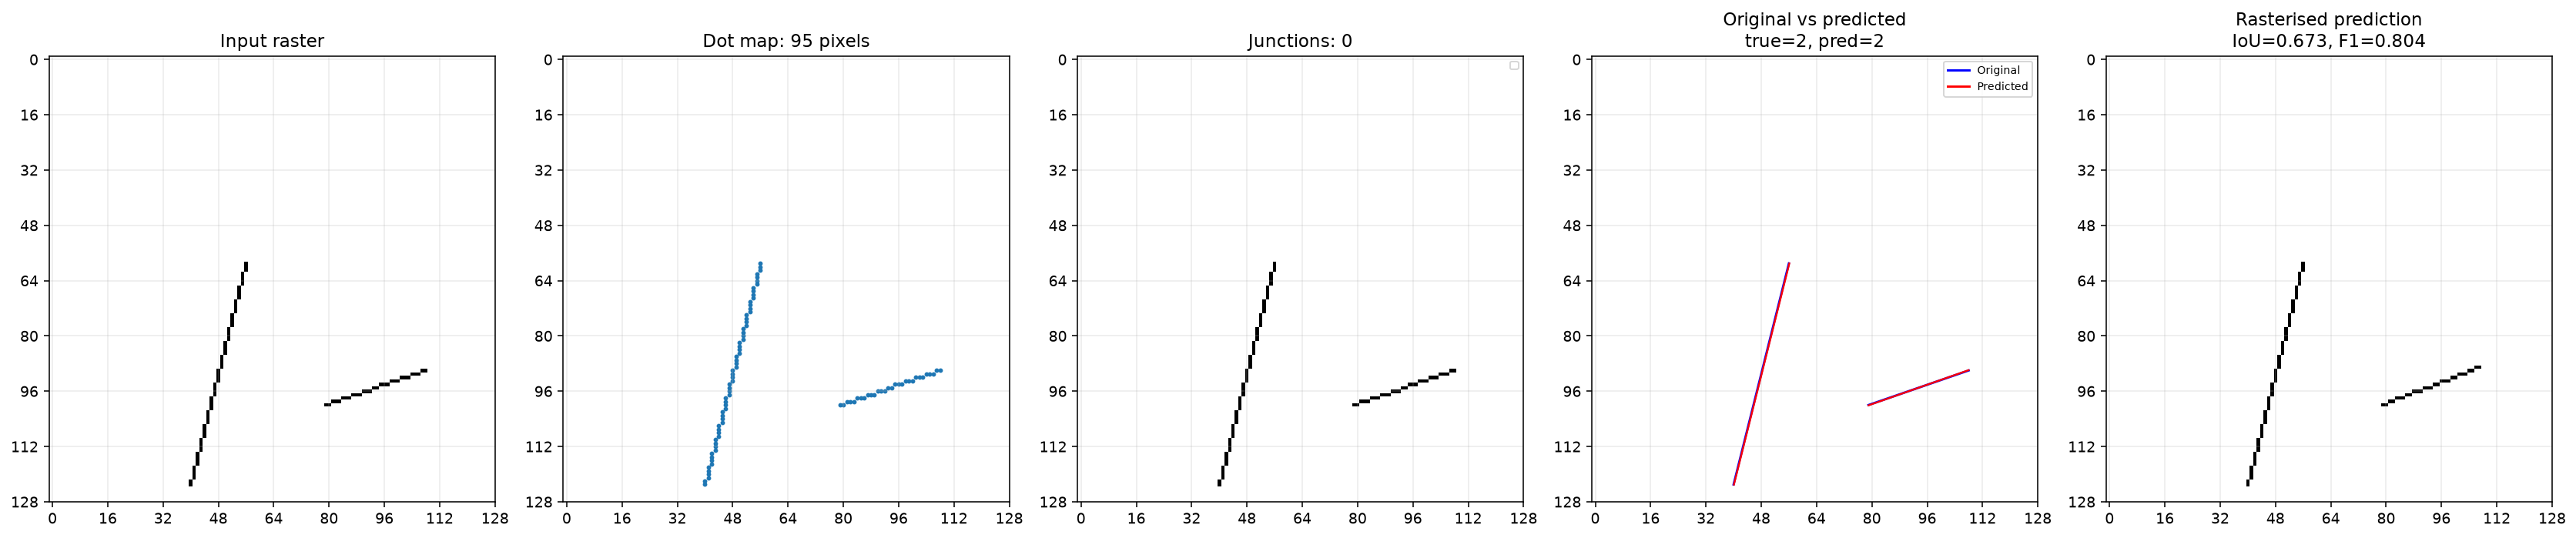

Sample 155
merge_collinear_lines: input=2, output=2, merges=0, comparisons=0


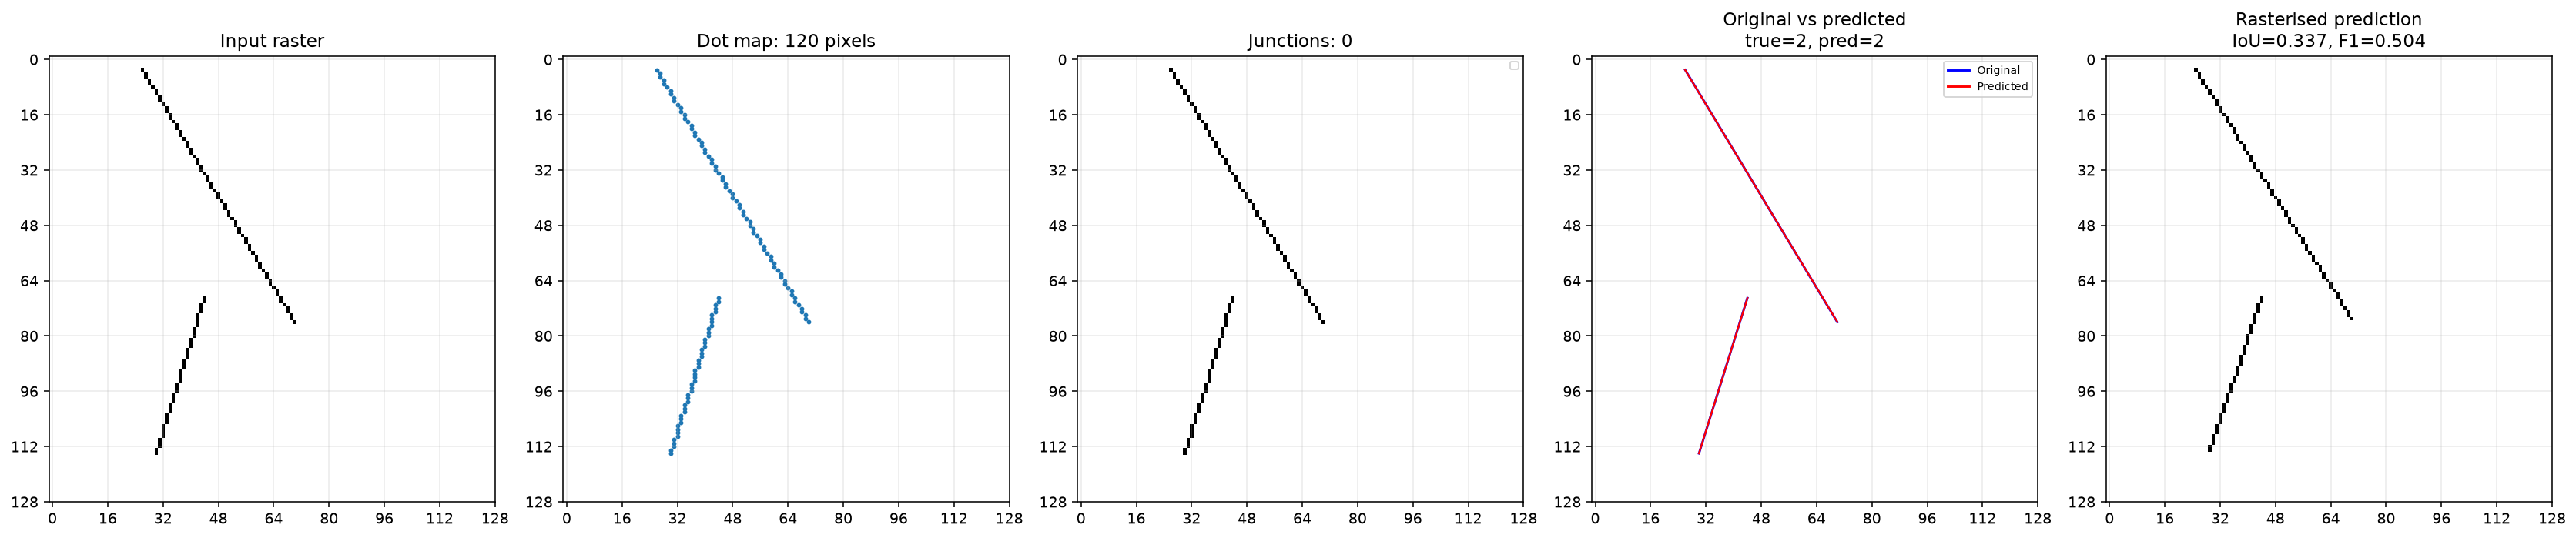

Sample 14


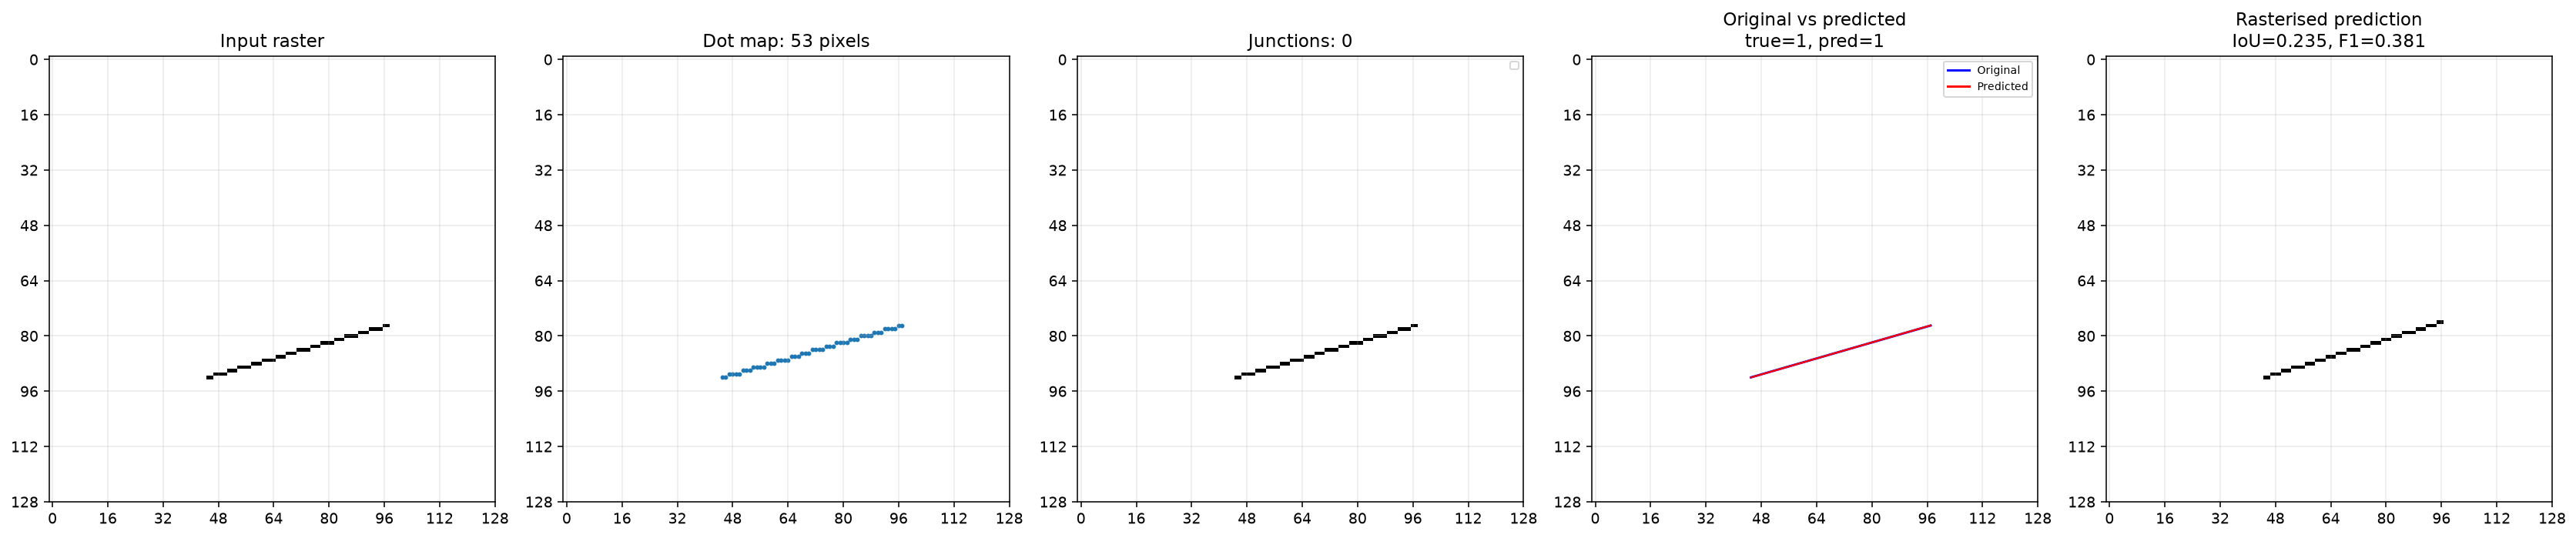

Sample 74


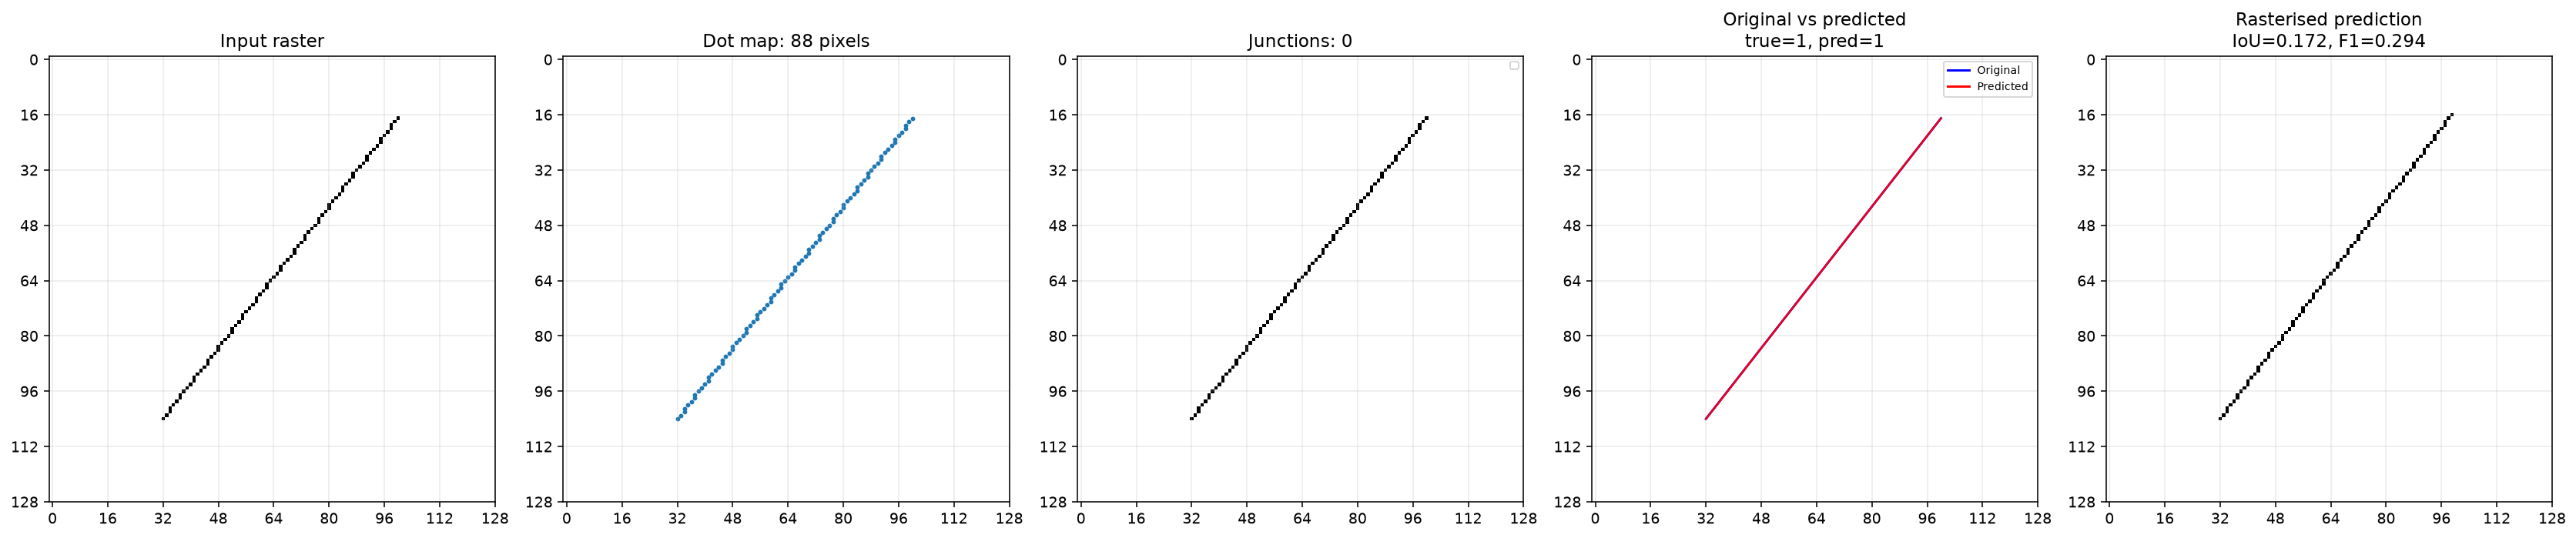

Sample 40
merge_collinear_lines: input=2, output=2, merges=0, comparisons=0


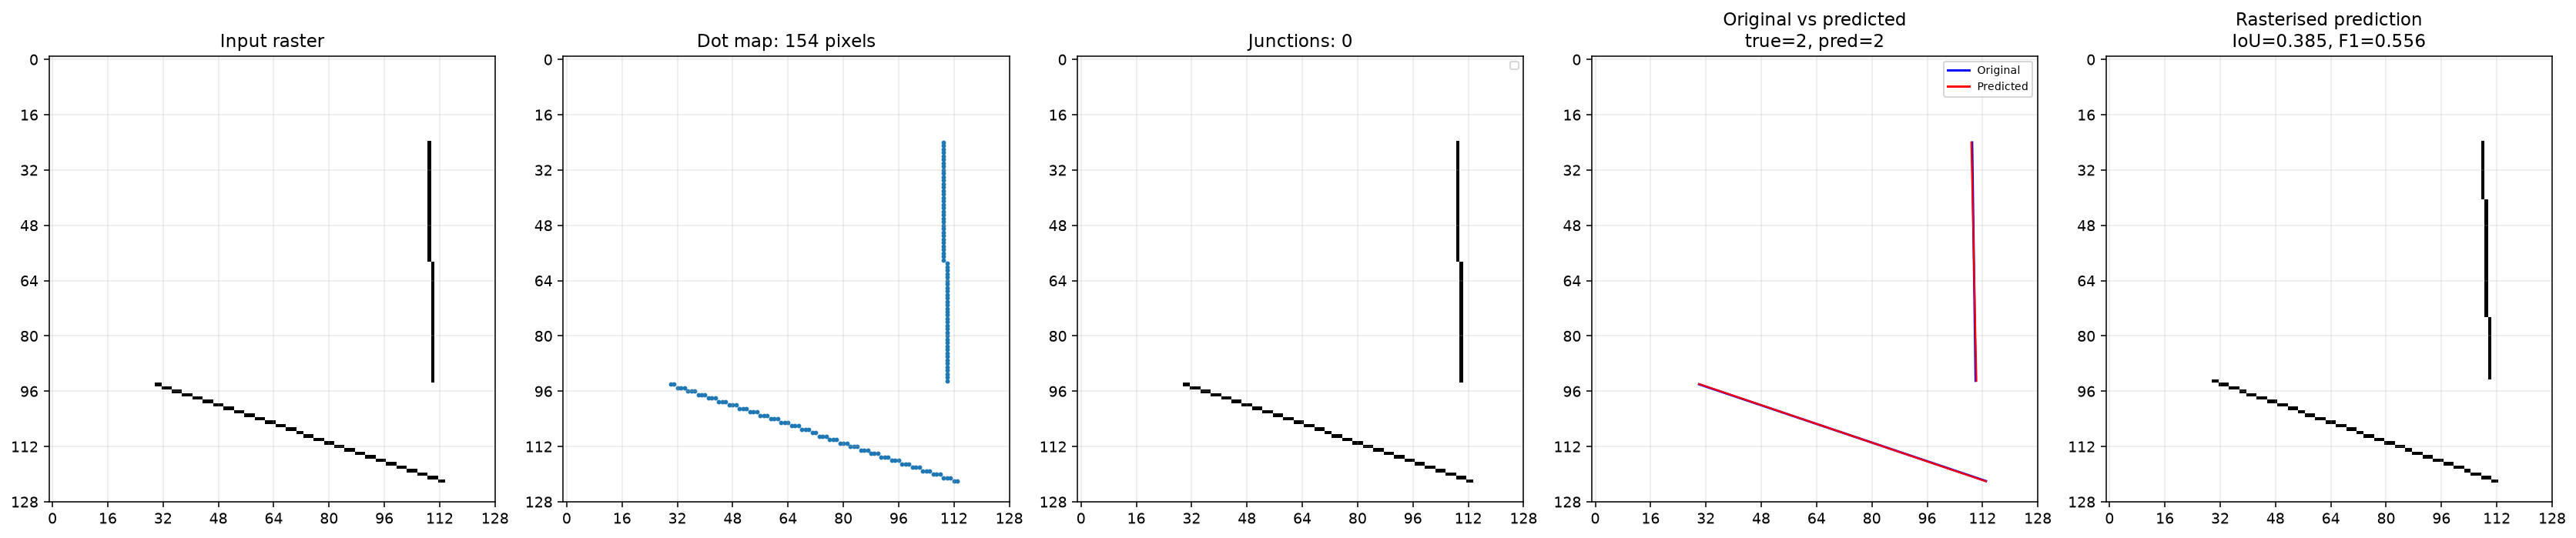

Sample 102
merge_collinear_lines: input=5, output=5, merges=0, comparisons=0


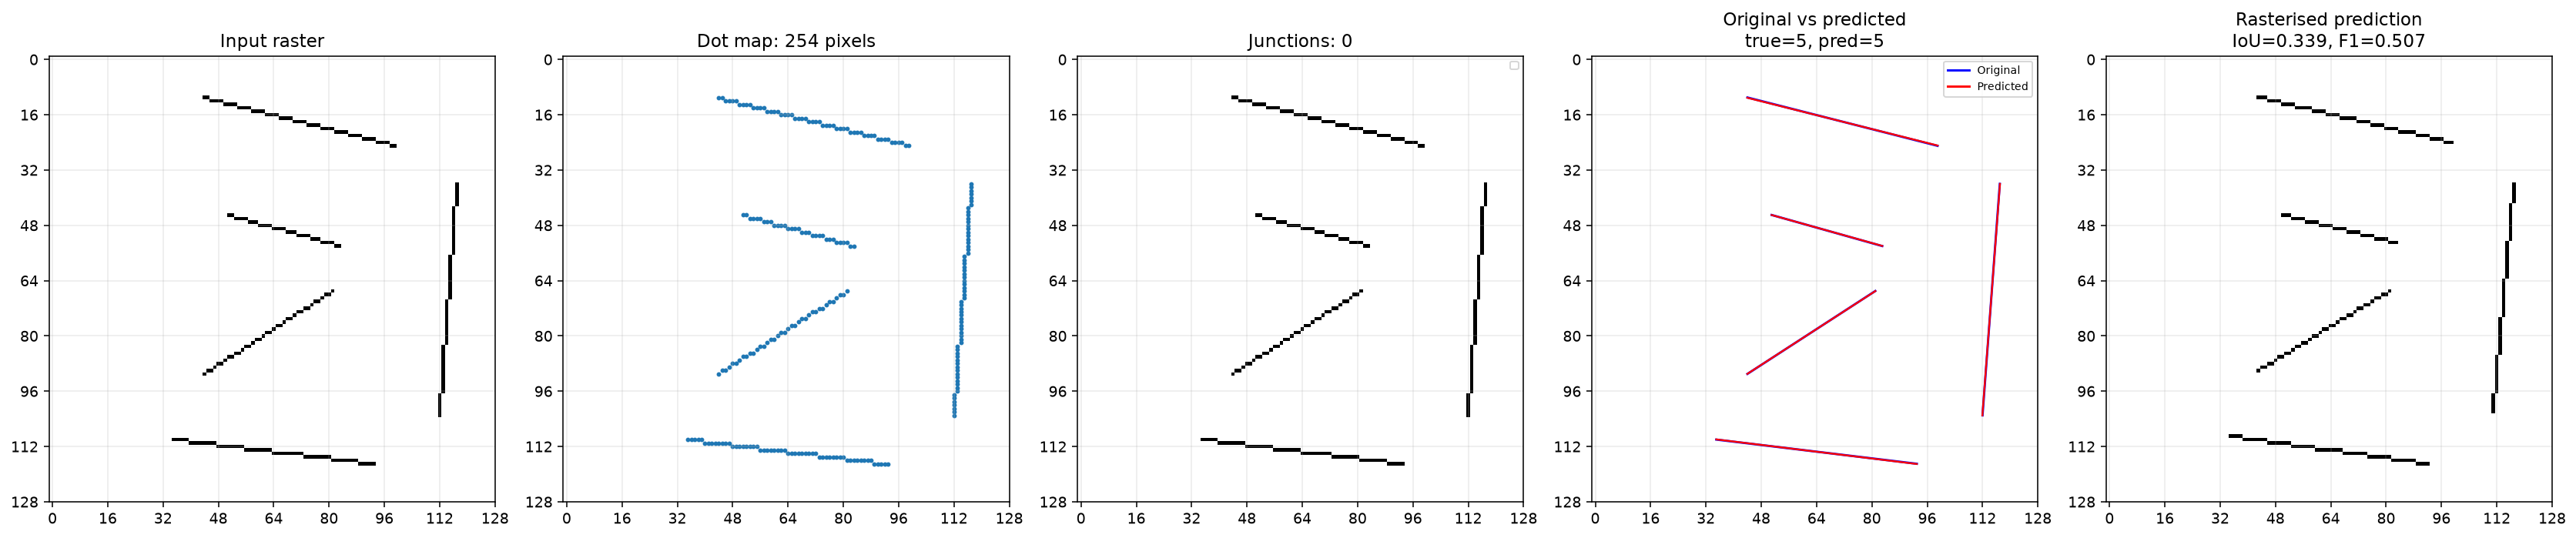

Sample 54
merge_collinear_lines: input=20, output=15, merges=5, comparisons=69


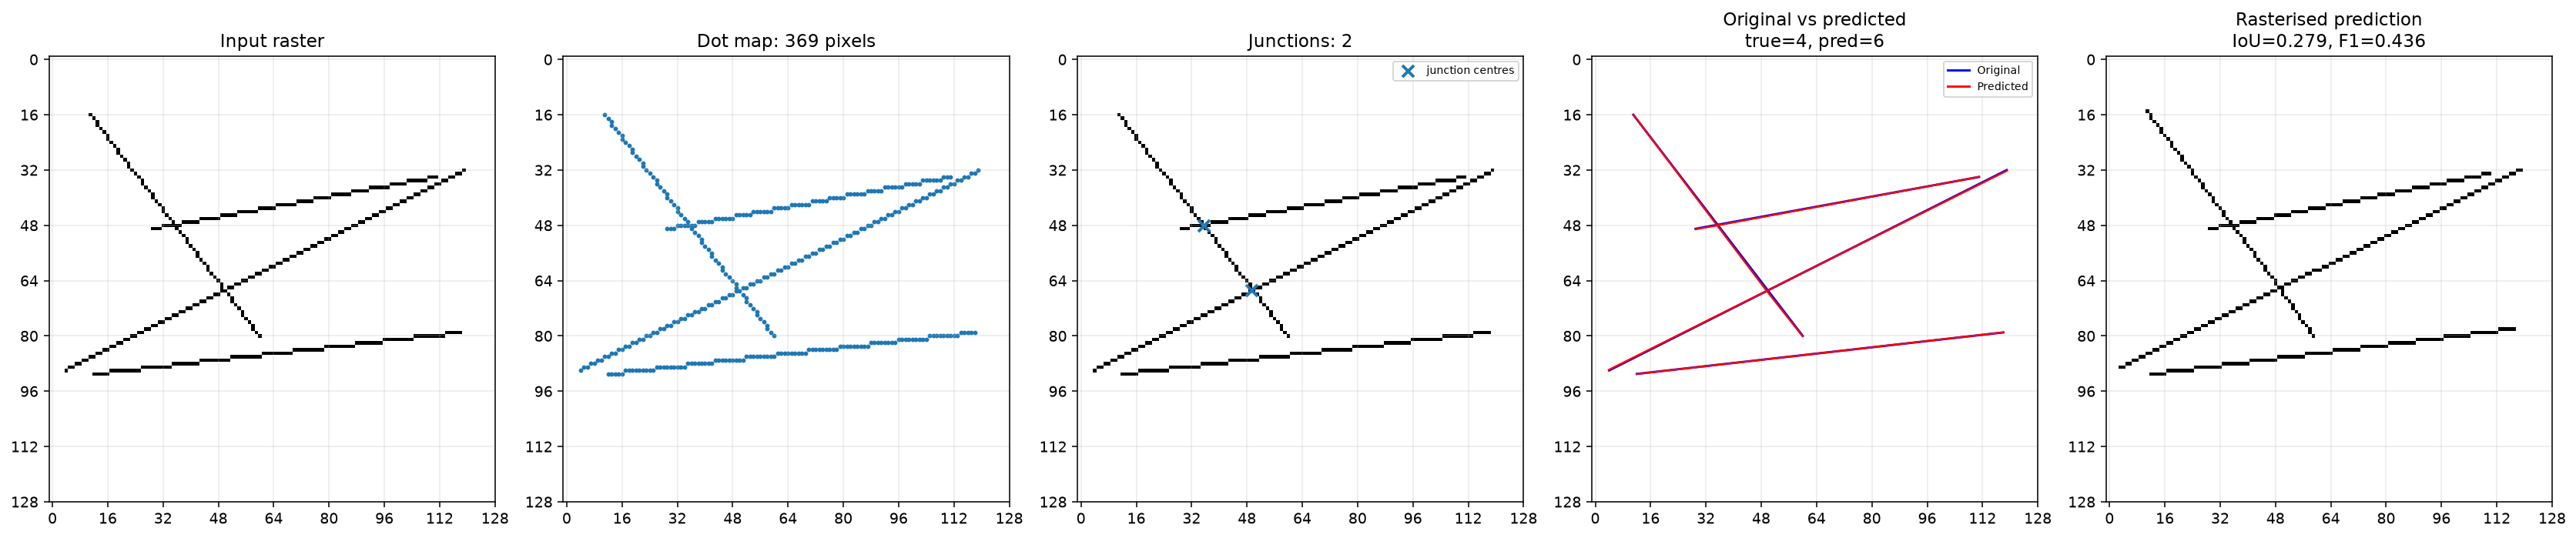

Sample 134
merge_collinear_lines: input=30, output=19, merges=11, comparisons=127


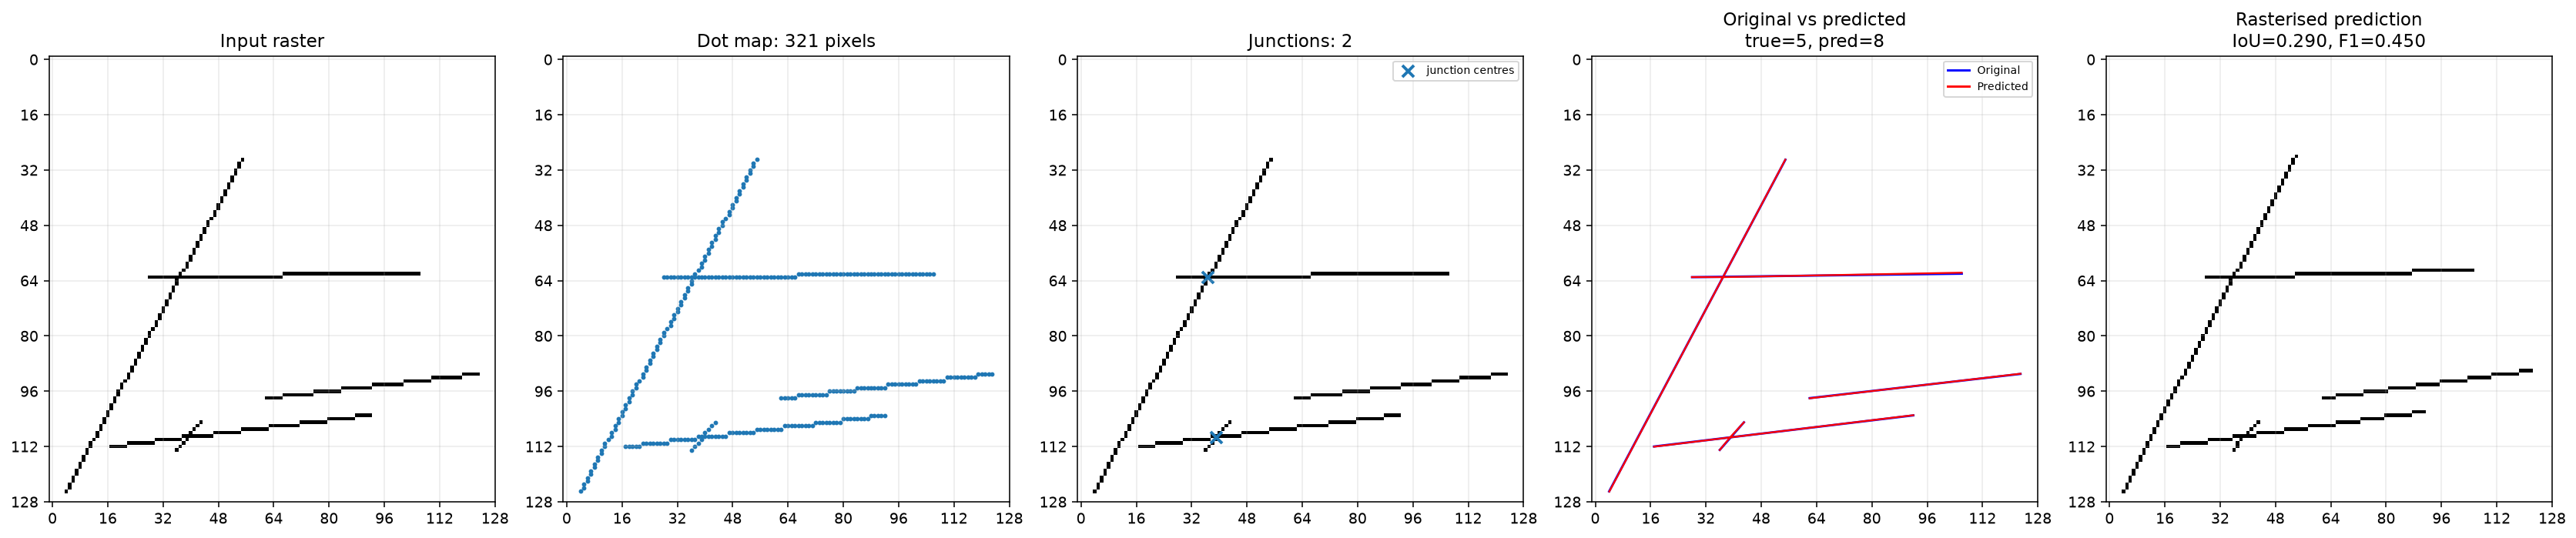

Sample 165
merge_collinear_lines: input=35, output=22, merges=13, comparisons=224


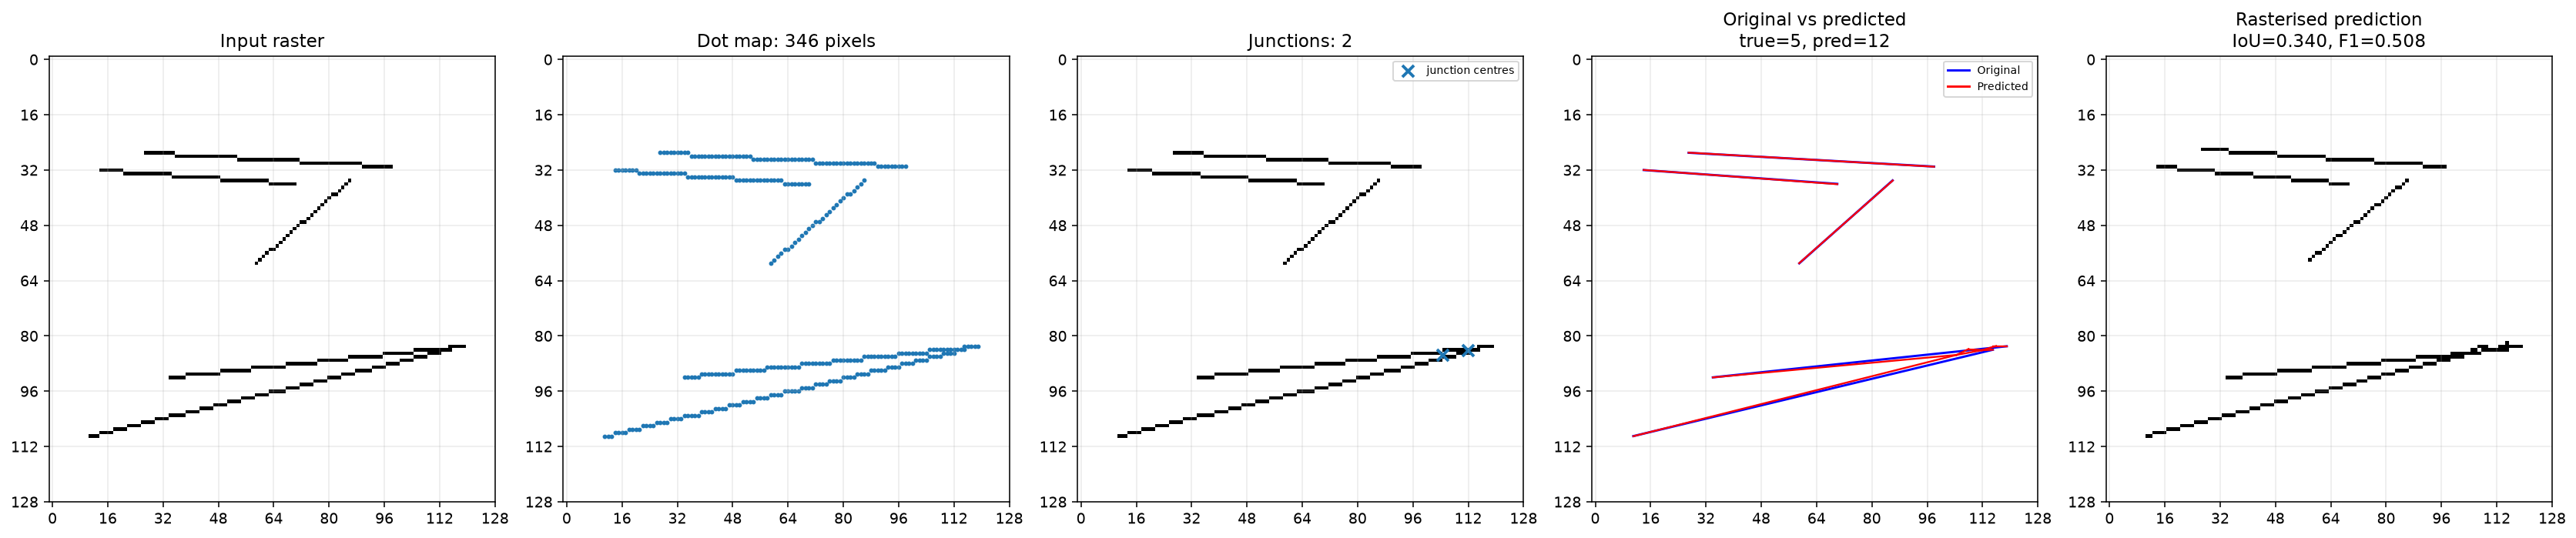

Sample 137
merge_collinear_lines: input=13, output=7, merges=6, comparisons=36


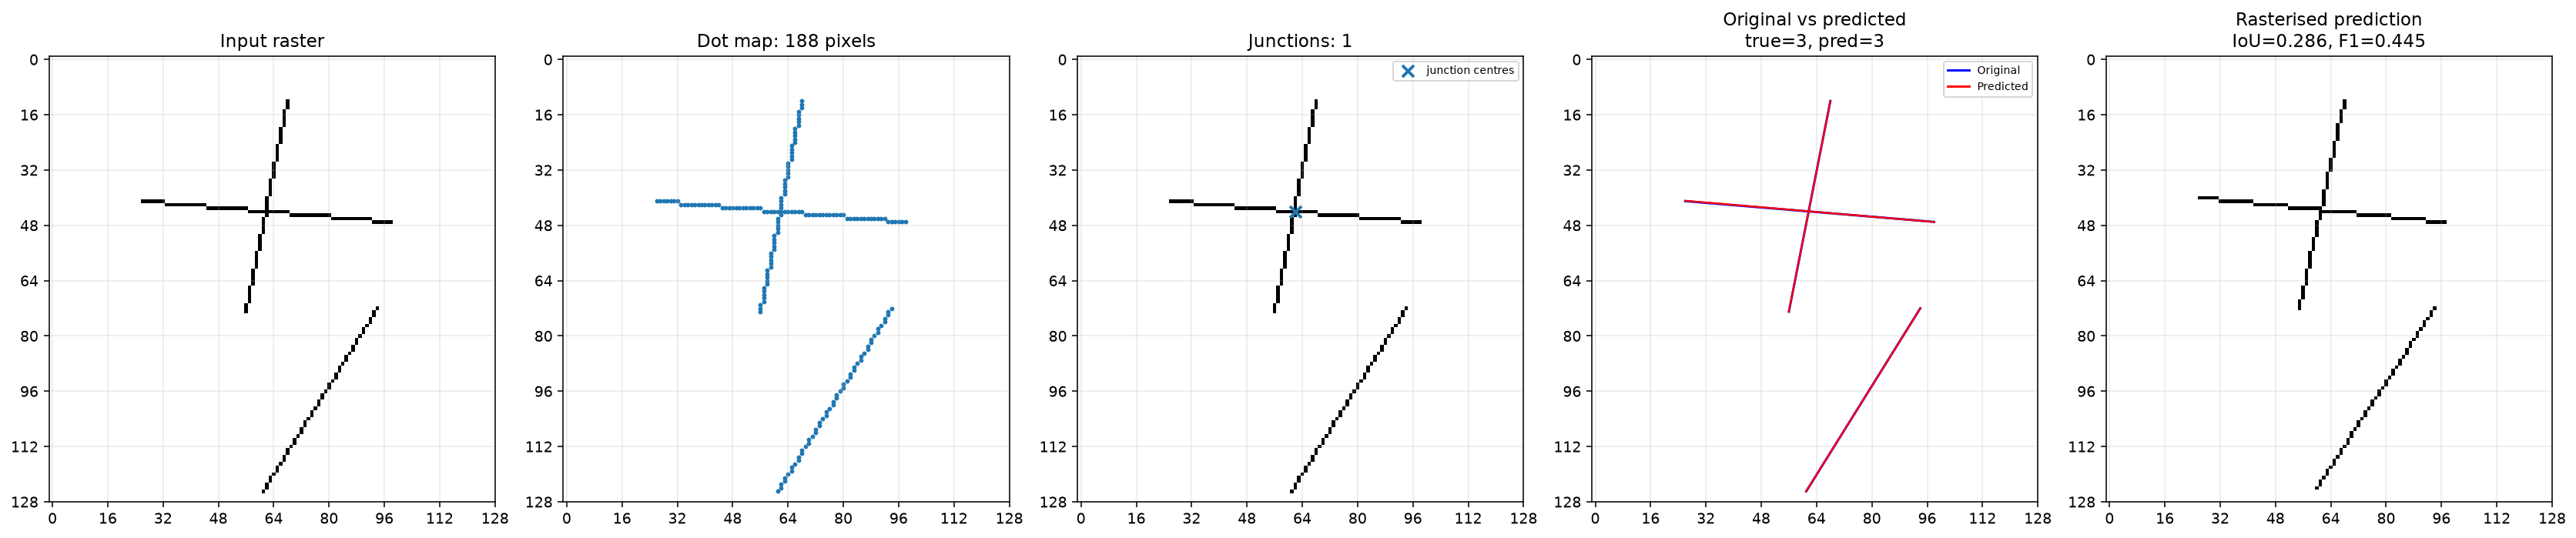

In [15]:
# Show 10 random examples
# N_TEST is used here as an alias for this notebook's generated test/sample set.
N_TEST = N_SAMPLES
random_indices = random.sample(range(N_TEST), 10)
print('Random sample indices:', random_indices)

for idx in random_indices:
    print('=' * 100)
    print(f'Sample {idx}')
    show_result(idx)

## 11. Export random samples as SVG vector layers

This exports the same `random_indices` shown above.

- Blue layer: original synthetic vectors
- Red layer: predicted vectors

Open the SVG files in a browser, Inkscape, Illustrator, or a CAD/vector editor for visual inspection.

In [16]:
from pathlib import Path
import xml.etree.ElementTree as ET

EXPORT_DIR = Path("vector_exports")
EXPORT_DIR.mkdir(exist_ok=True)

# Compatibility aliases for the export cell.
test_images = raster_images
test_vectors = true_vectors


def as_xyxy(line):
    """Return x0, y0, x1, y1 from either a Line object or a tuple/list."""
    if hasattr(line, "x1"):
        return float(line.x1), float(line.y1), float(line.x2), float(line.y2)
    return tuple(map(float, line))


def reconstruct_vectors_from_image(image):
    """Compatibility wrapper used by the SVG export code."""
    result = vectorise_raster_adaptive(image)
    predicted_vectors = result["merged_lines"]
    return predicted_vectors, result


def export_sample_svg(idx, image_set=test_images, truth_set=test_vectors, filename=None):
    image = image_set[idx]
    original_vectors = truth_set[idx]
    predicted_vectors, debug = reconstruct_vectors_from_image(image)

    if filename is None:
        filename = EXPORT_DIR / f"sample_{idx}_original_vs_predicted.svg"

    scale = 6
    W = IMG_SIZE * scale
    H = IMG_SIZE * scale

    svg = ET.Element(
        "svg",
        {
            "xmlns": "http://www.w3.org/2000/svg",
            "width": str(W),
            "height": str(H),
            "viewBox": f"0 0 {IMG_SIZE} {IMG_SIZE}",
        },
    )

    # White background
    ET.SubElement(svg, "rect", {
        "x": "0", "y": "0",
        "width": str(IMG_SIZE),
        "height": str(IMG_SIZE),
        "fill": "white"
    })

    # Original vectors layer: blue
    original_layer = ET.SubElement(svg, "g", {
        "id": "original_vectors",
        "stroke": "blue",
        "stroke-width": "1",
        "fill": "none",
        "stroke-linecap": "round"
    })

    for line in original_vectors:
        x0, y0, x1, y1 = as_xyxy(line)
        ET.SubElement(original_layer, "line", {
            "x1": str(x0), "y1": str(y0),
            "x2": str(x1), "y2": str(y1)
        })

    # Predicted vectors layer: red
    predicted_layer = ET.SubElement(svg, "g", {
        "id": "predicted_vectors",
        "stroke": "red",
        "stroke-width": "1",
        "fill": "none",
        "stroke-linecap": "round"
    })

    for line in predicted_vectors:
        x0, y0, x1, y1 = as_xyxy(line)
        ET.SubElement(predicted_layer, "line", {
            "x1": str(x0), "y1": str(y0),
            "x2": str(x1), "y2": str(y1)
        })

    tree = ET.ElementTree(svg)
    tree.write(filename, encoding="utf-8", xml_declaration=True)

    print(f"Exported sample {idx}")
    print(f"Original vectors:  {len(original_vectors)}")
    print(f"Predicted vectors: {len(predicted_vectors)}")
    print(f"Saved to: {filename}")

    return filename


# Export the same random samples from the display cell above.
exported_files = []

for idx in random_indices:
    exported_files.append(export_sample_svg(idx))

exported_files

merge_collinear_lines: input=2, output=2, merges=0, comparisons=0
Exported sample 144
Original vectors:  2
Predicted vectors: 2
Saved to: vector_exports\sample_144_original_vs_predicted.svg
merge_collinear_lines: input=2, output=2, merges=0, comparisons=0
Exported sample 155
Original vectors:  2
Predicted vectors: 2
Saved to: vector_exports\sample_155_original_vs_predicted.svg
Exported sample 14
Original vectors:  1
Predicted vectors: 1
Saved to: vector_exports\sample_14_original_vs_predicted.svg
Exported sample 74
Original vectors:  1
Predicted vectors: 1
Saved to: vector_exports\sample_74_original_vs_predicted.svg
merge_collinear_lines: input=2, output=2, merges=0, comparisons=0
Exported sample 40
Original vectors:  2
Predicted vectors: 2
Saved to: vector_exports\sample_40_original_vs_predicted.svg
merge_collinear_lines: input=5, output=5, merges=0, comparisons=0
Exported sample 102
Original vectors:  5
Predicted vectors: 5
Saved to: vector_exports\sample_102_original_vs_predicted.sv

[WindowsPath('vector_exports/sample_144_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_155_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_14_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_74_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_40_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_102_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_54_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_134_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_165_original_vs_predicted.svg'),
 WindowsPath('vector_exports/sample_137_original_vs_predicted.svg')]

## 11. Dataset-level evaluation

This gives a simple quantitative baseline over all generated samples.


In [17]:
all_metrics = []
vector_count_rows = []

for i in range(N_SAMPLES):
    result = vectorise_raster_adaptive(raster_images[i])
    pred_raster = raster_from_predicted_lines(result['merged_lines'])
    m = raster_metrics(raster_images[i], pred_raster)
    all_metrics.append(m)
    vector_count_rows.append((len(true_vectors[i]), len(result['merged_lines'])))

mean_metrics = {k: float(np.mean([m[k] for m in all_metrics])) for k in ['precision', 'recall', 'f1', 'iou']}
print('Mean raster metrics:')
for k, v in mean_metrics.items():
    print(f'{k}: {v:.3f}')

true_counts = np.array([r[0] for r in vector_count_rows])
pred_counts = np.array([r[1] for r in vector_count_rows])
print('\nVector count accuracy:', float(np.mean(true_counts == pred_counts)))
print('Mean true vector count:', true_counts.mean())
print('Mean predicted vector count:', pred_counts.mean())


merge_collinear_lines: input=75, output=45, merges=30, comparisons=533
merge_collinear_lines: input=24, output=15, merges=9, comparisons=68
merge_collinear_lines: input=12, output=8, merges=4, comparisons=20
merge_collinear_lines: input=2, output=2, merges=0, comparisons=0
merge_collinear_lines: input=9, output=7, merges=2, comparisons=29
merge_collinear_lines: input=53, output=31, merges=22, comparisons=254
merge_collinear_lines: input=16, output=12, merges=4, comparisons=66
merge_collinear_lines: input=28, output=21, merges=7, comparisons=131
merge_collinear_lines: input=14, output=10, merges=4, comparisons=39
merge_collinear_lines: input=27, output=18, merges=9, comparisons=94
merge_collinear_lines: input=37, output=22, merges=15, comparisons=138
merge_collinear_lines: input=2, output=2, merges=0, comparisons=0
merge_collinear_lines: input=35, output=24, merges=11, comparisons=207
merge_collinear_lines: input=2, output=2, merges=0, comparisons=0
merge_collinear_lines: input=2, outpu

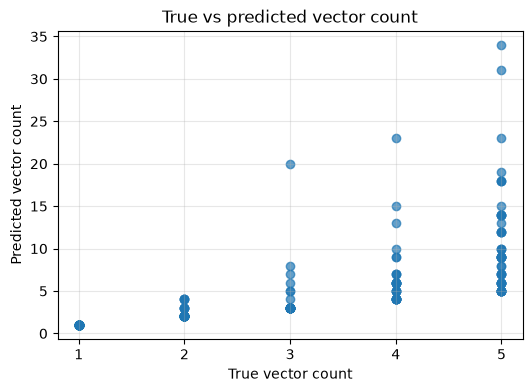

In [18]:
plt.figure(figsize=(6, 4))
plt.scatter(true_counts, pred_counts, alpha=0.7)
plt.xlabel('True vector count')
plt.ylabel('Predicted vector count')
plt.title('True vs predicted vector count')
plt.xticks(range(1, MAX_LINES + 1))
plt.grid(True, alpha=0.3)
plt.show()


## 12. Notes for extension

Useful next steps:

- Add controlled noise and test robustness.
- Add curves and recursively split branches where line fit error is high.
- Compare this method against Hough Transform, contour tracing, skeletonisation, and a neural network model.
- Add endpoint distance metrics, not just raster IoU.
- Export predicted vectors as JSON, SVG, or DXF-like line data.
